## Bank Load Analysis

#### Import Libraries

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px


In [58]:
df = pd.read_excel("C:/Users/MIKE/Desktop/Python Projects/financial_loan.xlsx")

In [59]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


### Metadata of Data

In [60]:
print("No. of Rows:", df.shape[0])

No. of Rows: 38576


In [61]:
print("No. of Columns:", df.shape[1])

No. of Columns: 24


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  str           
 2   application_type       38576 non-null  str           
 3   emp_length             38576 non-null  str           
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  str           
 6   home_ownership         38576 non-null  str           
 7   issue_date             38576 non-null  datetime64[us]
 8   last_credit_pull_date  38576 non-null  datetime64[us]
 9   last_payment_date      38576 non-null  datetime64[us]
 10  loan_status            38576 non-null  str           
 11  next_payment_date      38576 non-null  datetime64[us]
 12  member_id              38576 non-null  int64         
 13  purpose     

In [63]:
df.dtypes

id                                int64
address_state                       str
application_type                    str
emp_length                          str
emp_title                        object
grade                               str
home_ownership                      str
issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
loan_status                         str
next_payment_date        datetime64[us]
member_id                         int64
purpose                             str
sub_grade                           str
term                                str
verification_status                 str
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [64]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007,2021-06-08 13:36:34.193280,2021-06-26 09:52:08.909166,2021-07-26 20:42:20.605557,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


#### Total Loan Application

In [65]:
total_load_application = df['id'].count()
print("Total Loan Applications:", total_load_application)

Total Loan Applications: 38576


#### MTD Total Loan Application


In [66]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_loan_applications = df[
	(df['issue_date'].dt.year == latest_year) &
	(df['issue_date'].dt.month == latest_month)
]['id'].count()

print(f"MTD Loan Applications (for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")

MTD Loan Applications (for December 2021): 4314


#### Total Funded Amount


In [67]:
total_funded_amount = df['loan_amount'].sum()
print("Total Funded Amount:", total_funded_amount)

total_funded_amount_millions = total_funded_amount / 1000000
print(f"Total Funded Amount in Millions: ${total_funded_amount_millions:.2f}M")

Total Funded Amount: 435757075
Total Funded Amount in Millions: $435.76M


#### MTD - Total Funded Amount


In [68]:
mtd_total_funded_amount = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]['loan_amount'].sum()
mtd_total_funded_amount_millions = mtd_total_funded_amount / 1000000
print(f"MTD Total Funded Amount: ${mtd_total_funded_amount_millions:.2f}M")

MTD Total Funded Amount: $53.98M


#### Monthly Trends by Issue Date for Total Funded Amount

To identify seasonality and long-term trends in lending activity, we aggregate funded amount by loan issue month.

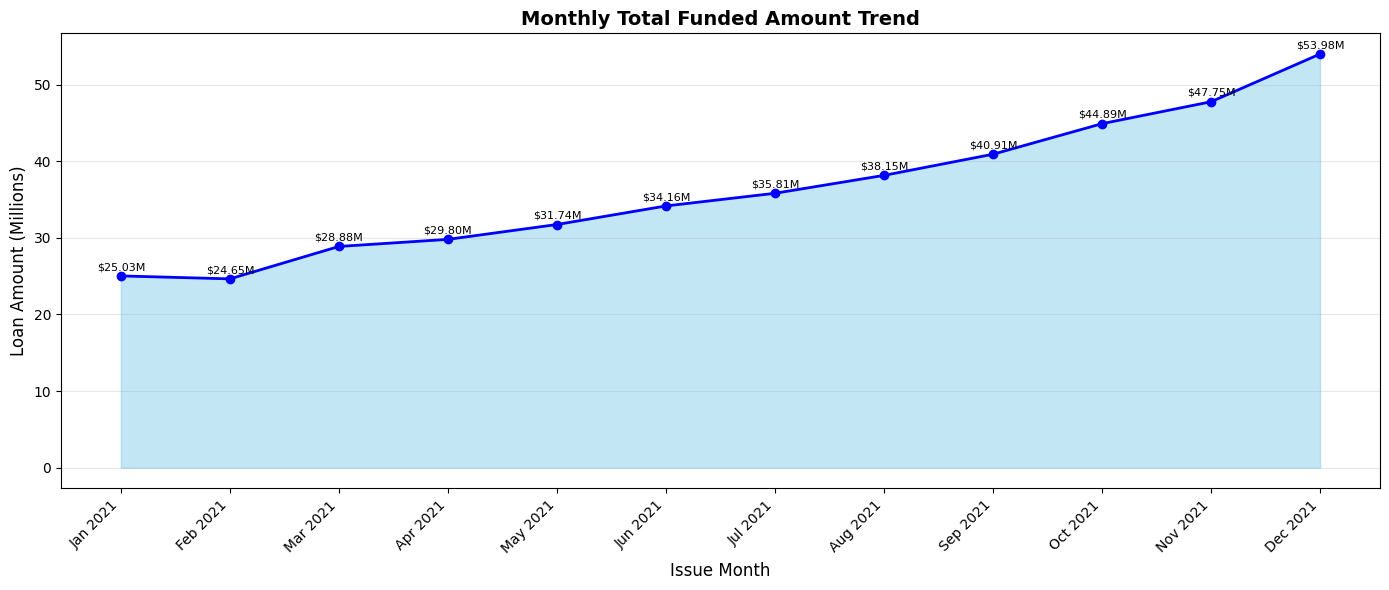

In [69]:
monthly_funded = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['loan_amount']
      .sum()
      .div(1000000)
      .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(14, 6))
plt.fill_between(range(len(monthly_funded)), monthly_funded['loan_amount_millions'], color='skyblue', alpha=0.5)
plt.plot(range(len(monthly_funded)), monthly_funded['loan_amount_millions'], color='blue', linewidth=2, marker='o')

for i, row in monthly_funded.iterrows():
    plt.text(i, row['loan_amount_millions'] + 0.5, f"${row['loan_amount_millions']:.2f}M",
             ha='center', va='bottom', fontsize=8, rotation=0, color='black')

plt.xlabel('Issue Month', fontsize=12)
plt.ylabel('Loan Amount (Millions)', fontsize=12)
plt.title('Monthly Total Funded Amount Trend', fontsize=14, fontweight='bold')
plt.xticks(range(len(monthly_funded)), monthly_funded['month_name'], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Monthly Trends by Issue Date for Total Amount Received

To identify seasonality and long-term trends in loan repayment activities, we analyze the total amount received by loan issue month.

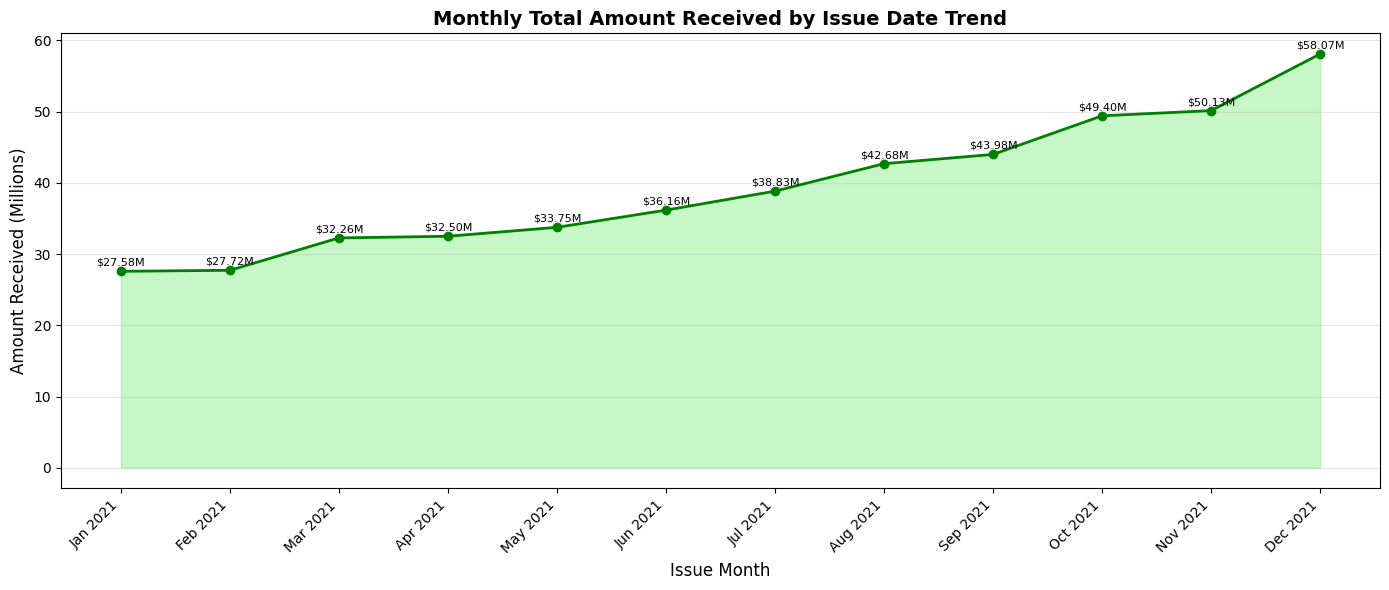

In [70]:
monthly_received = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['total_payment']
      .sum()
      .div(1000000)
      .reset_index(name='amount_received_millions')
)

plt.figure(figsize=(14, 6))
plt.fill_between(range(len(monthly_received)), monthly_received['amount_received_millions'], color='lightgreen', alpha=0.5)
plt.plot(range(len(monthly_received)), monthly_received['amount_received_millions'], color='green', linewidth=2, marker='o')

for i, row in monthly_received.iterrows():
    plt.text(i, row['amount_received_millions'] + 0.5, f"${row['amount_received_millions']:.2f}M",
             ha='center', va='bottom', fontsize=8, rotation=0, color='black')

plt.xlabel('Issue Month', fontsize=12)
plt.ylabel('Amount Received (Millions)', fontsize=12)
plt.title('Monthly Total Amount Received by Issue Date Trend', fontsize=14, fontweight='bold')
plt.xticks(range(len(monthly_received)), monthly_received['month_name'], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Monthly Trends by Issue Date for Total Loan Application

To analyze lending volume trends and seasonality, we track the number of loan applications issued each month.

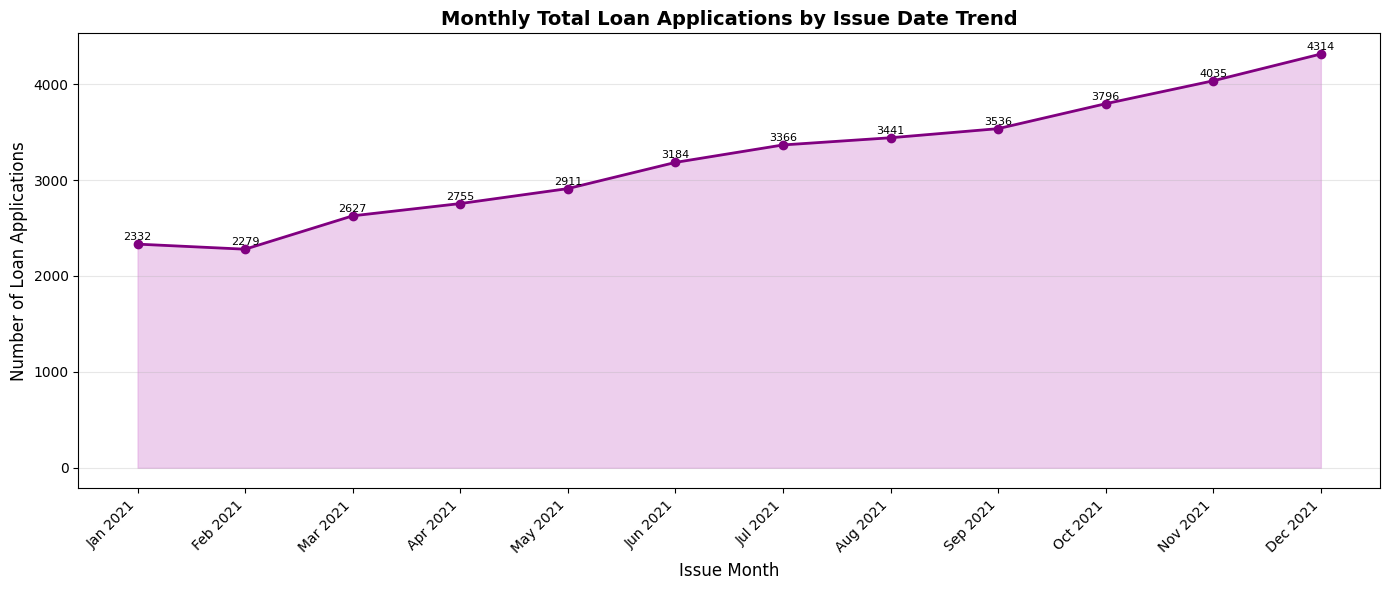

In [71]:
monthly_applications = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)
      .size()
      .reset_index(name='loan_count')
)

plt.figure(figsize=(14, 6))
plt.fill_between(range(len(monthly_applications)), monthly_applications['loan_count'], color='plum', alpha=0.5)
plt.plot(range(len(monthly_applications)), monthly_applications['loan_count'], color='purple', linewidth=2, marker='o')

for i, row in monthly_applications.iterrows():
    plt.text(i, row['loan_count'] + 20, f"{row['loan_count']:.0f}",
             ha='center', va='bottom', fontsize=8, rotation=0, color='black')

plt.xlabel('Issue Month', fontsize=12)
plt.ylabel('Number of Loan Applications', fontsize=12)
plt.title('Monthly Total Loan Applications by Issue Date Trend', fontsize=14, fontweight='bold')
plt.xticks(range(len(monthly_applications)), monthly_applications['month_name'], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Regional Analysis by State

Analyze lending patterns across different states to identify regional trends, popular loan destinations, and geographic performance.

Top 10 States by Total Funded Amount:

               loan_count  total_funded_amount_millions  \
address_state                                             
CA                   6894                     78.484125   
NY                   3701                     42.077050   
TX                   2664                     31.236650   
FL                   2773                     30.046125   
NJ                   1822                     21.657475   
IL                   1486                     17.124225   
VA                   1375                     15.982650   
PA                   1482                     15.826525   
GA                   1355                     15.480325   
MA                   1310                     15.051000   

               total_received_millions  avg_interest_rate_pct  
address_state                                                  
CA                           83.901234              12.148225  
NY                           46.108181              12.11434

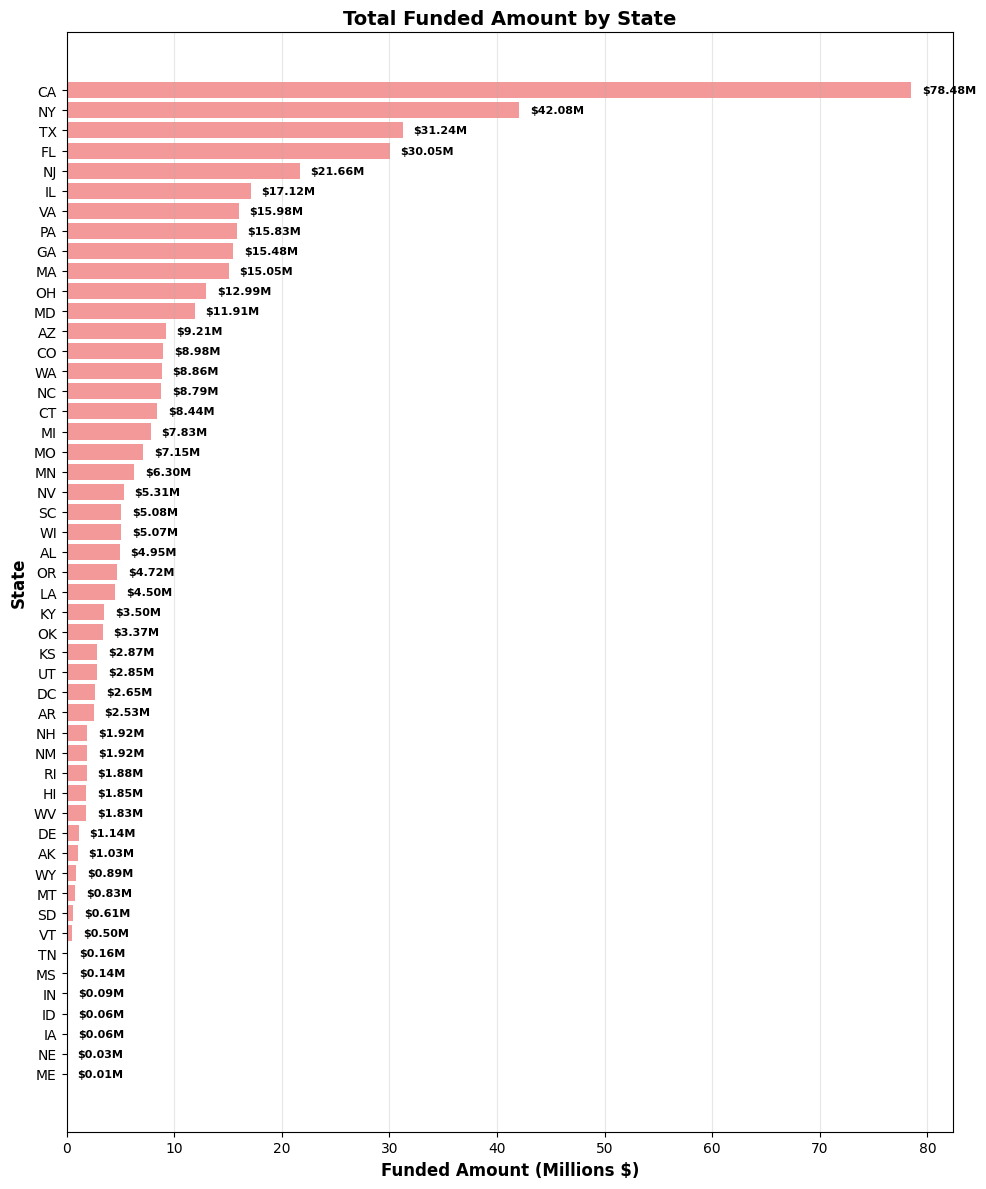

In [72]:
state_analysis = (
    df.groupby('address_state')
      .agg({
          'id': 'count',
          'loan_amount': 'sum',
          'total_payment': 'sum',
          'int_rate': 'mean'
      })
      .rename(columns={
          'id': 'loan_count',
          'loan_amount': 'total_funded_amount',
          'total_payment': 'total_received',
          'int_rate': 'avg_interest_rate'
      })
      .sort_values('total_funded_amount', ascending=False)
)

state_analysis['total_funded_amount_millions'] = state_analysis['total_funded_amount'] / 1_000_000
state_analysis['total_received_millions'] = state_analysis['total_received'] / 1_000_000
state_analysis['avg_interest_rate_pct'] = state_analysis['avg_interest_rate'] * 100

print("Top 10 States by Total Funded Amount:\n")
print(state_analysis[['loan_count', 'total_funded_amount_millions', 'total_received_millions', 'avg_interest_rate_pct']].head(10))

# Visualization - Horizontal Bar Chart
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_millions = state_funding / 1_000_000

plt.figure(figsize=(10, 12))
bars = plt.barh(state_funding_millions.index, state_funding_millions.values, color='lightcoral', alpha=0.8)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height() / 2,
             f'${width:.2f}M', va='center', fontsize=8, fontweight='bold')

plt.title('Total Funded Amount by State', fontsize=14, fontweight='bold')
plt.xlabel('Funded Amount (Millions $)', fontsize=12, fontweight='bold')
plt.ylabel('State', fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### Loan Term Analysis by Total Funded Amount

Evaluate how funded amount distributes across loan terms to understand whether certain terms are driving higher lending volume.

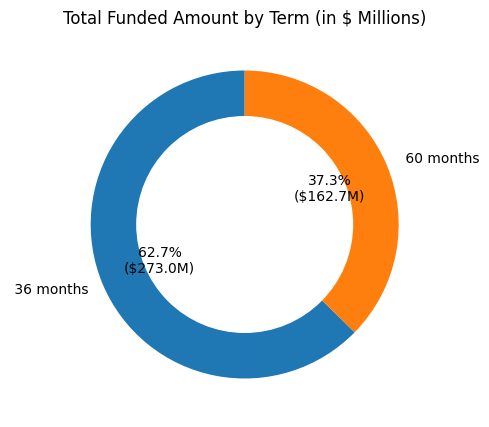

In [79]:
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize=(5, 5))
plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n(${p * sum(term_funding_millions) / 100:.1f}M)",
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))
plt.title("Total Funded Amount by Term (in $ Millions)")
plt.show()

#### Employee Length Analysis by Total Funded Amount

This analysis shows how total loan funding is distributed across employee length categories.

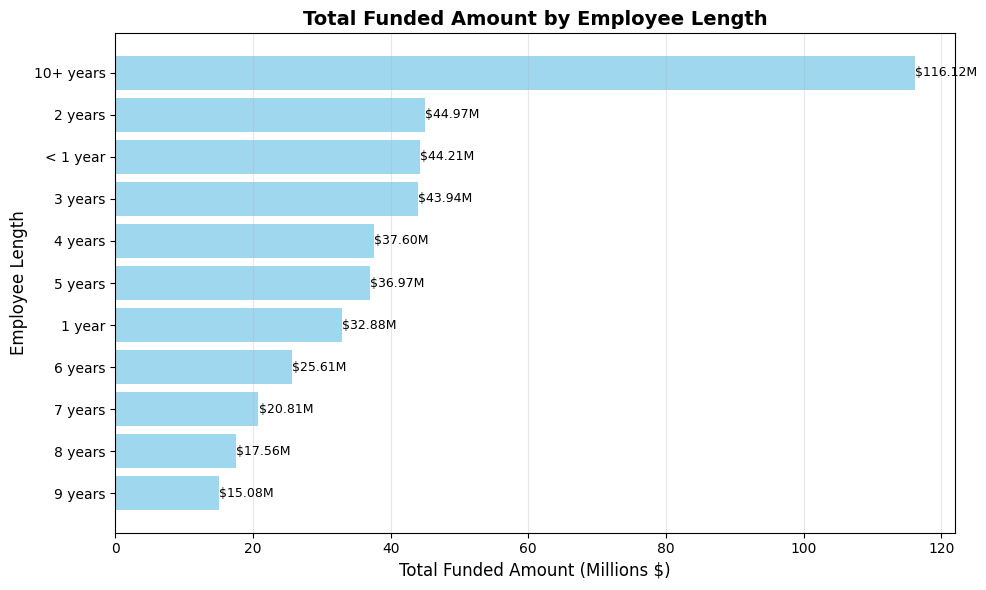

In [80]:
employee_length_funding = (
    df.groupby('emp_length')['loan_amount']
      .sum()
      .sort_values(ascending=True)
)

employee_length_funding_millions = employee_length_funding / 1_000_000

plt.figure(figsize=(10, 6))
plt.barh(employee_length_funding_millions.index, employee_length_funding_millions.values, color='skyblue', alpha=0.8)

for idx, (emp_length, amount) in enumerate(employee_length_funding_millions.items()):
    plt.text(amount + 0.02, idx, f'${amount:.2f}M', va='center', fontsize=9)

plt.title('Total Funded Amount by Employee Length', fontsize=14, fontweight='bold')
plt.xlabel('Total Funded Amount (Millions $)', fontsize=12)
plt.ylabel('Employee Length', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### Loan Purpose Analysis by Total Funded Amount

Assess total funded amount by loan purpose to understand the main drivers of lending demand.

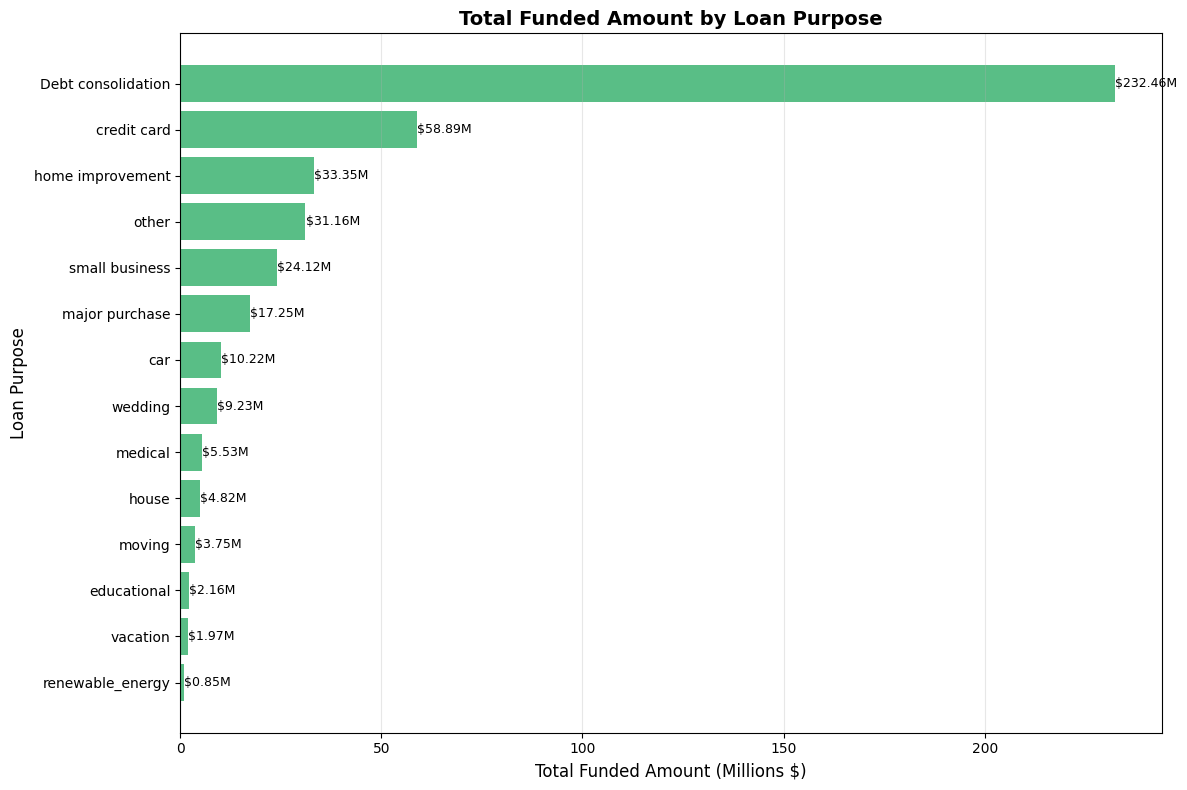

In [81]:
loan_purpose_funding = (
    df.groupby('purpose')['loan_amount']
      .sum()
      .sort_values(ascending=True)
)

loan_purpose_funding_millions = loan_purpose_funding / 1_000_000

plt.figure(figsize=(12, 8))
plt.barh(loan_purpose_funding_millions.index, loan_purpose_funding_millions.values, color='mediumseagreen', alpha=0.85)

for idx, (purpose, amount) in enumerate(loan_purpose_funding_millions.items()):
    plt.text(amount + 0.02, idx, f'${amount:.2f}M', va='center', fontsize=9)

plt.title('Total Funded Amount by Loan Purpose', fontsize=14, fontweight='bold')
plt.xlabel('Total Funded Amount (Millions $)', fontsize=12)
plt.ylabel('Loan Purpose', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### Home Ownership Analysis by Total Funded Amount

Analyze funded amount by home ownership status to identify lending patterns across ownership segments.

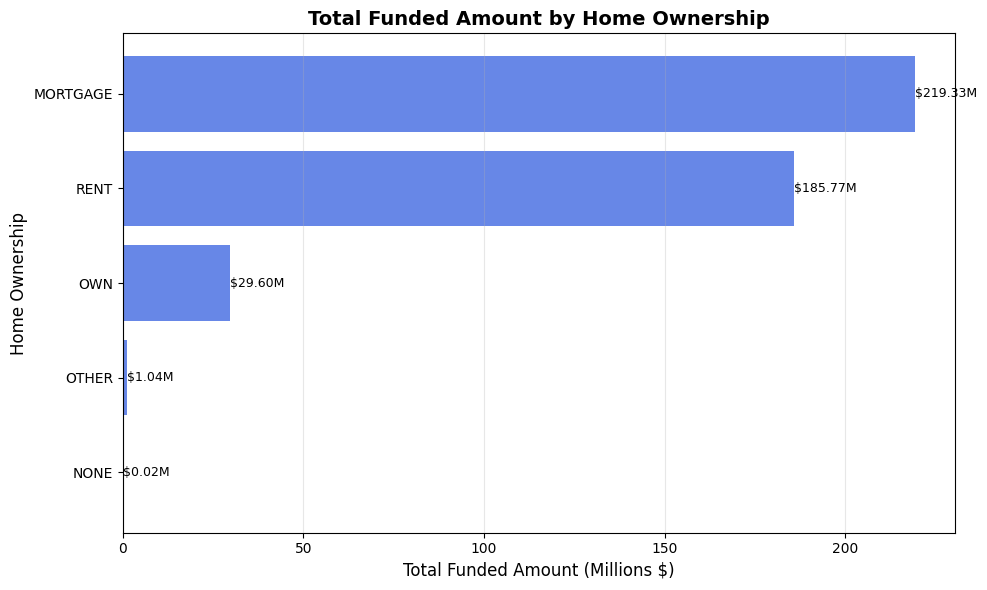

In [82]:
home_ownership_funding = (
    df.groupby('home_ownership')['loan_amount']
      .sum()
      .sort_values(ascending=True)
)

home_ownership_funding_millions = home_ownership_funding / 1_000_000

plt.figure(figsize=(10, 6))
plt.barh(home_ownership_funding_millions.index, home_ownership_funding_millions.values, color='royalblue', alpha=0.8)

for idx, (ownership, amount) in enumerate(home_ownership_funding_millions.items()):
    plt.text(amount + 0.02, idx, f'${amount:.2f}M', va='center', fontsize=9)

plt.title('Total Funded Amount by Home Ownership', fontsize=14, fontweight='bold')
plt.xlabel('Total Funded Amount (Millions $)', fontsize=12)
plt.ylabel('Home Ownership', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### MTD Total Amount Received

Total Amount Received: Tracking the total amount received from borrowers is essential for assessing the bank's cash flows and loan repayment. We should analyse the Month-to-Date (MTD) Total Amount Received.

In [73]:
mtd_total_amount_received = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]['total_payment'].sum()
mtd_total_amount_received_millions = mtd_total_amount_received / 1000000
print(f"MTD Total Amount Received: ${mtd_total_amount_received_millions:.2f}M")

MTD Total Amount Received: $58.07M


#### Average Interest Rate

Average Interest Rate: Calculating the average interest rate across all loans which will provide insights into our lending portfolio's overall cost.

In [74]:
average_interest_rate = df['int_rate'].mean()
print(f"Average Interest Rate: {average_interest_rate * 100:.2f}%")
print(f"Max Interest Rate: {df['int_rate'].max() * 100:.2f}%")

Average Interest Rate: 12.05%
Max Interest Rate: 24.59%


#### Average Debt-to-Income Ratio (DTI)

Average Debt-to-Income Ratio (DTI): Evaluating the average DTI for our borrowers helps us gauge their financial health. We need to compute the average DTI for all loans.

In [75]:
average_dti = df['dti'].mean()
print(f"Average DTI: {average_dti * 100:.2f}%")

Average DTI: 13.33%


#### Good Loan Metrics

Good Loan Metrics: Analyze the count, percentage, funded amount, and received amount for loans that are fully paid or current.

In [76]:
good_loans = df[df['loan_status'].isin(["Fully Paid", "Current"])]

total_loan_applications = df['id'].count()

good_loan_applications = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1000000
good_loan_received_millions = good_loan_received / 1000000

good_loan_percentage = (good_loan_applications / total_loan_applications) * 100

print("Good Loan Applications:", good_loan_applications)
print("Good Loan Funded Amount (in Millions): ${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Total Received (in Millions): ${:.2f}M".format(good_loan_received_millions))
print("Percentage of Good Loan Applications: {:.2f}%".format(good_loan_percentage))

Good Loan Applications: 33243
Good Loan Funded Amount (in Millions): $370.22M
Good Loan Total Received (in Millions): $435.79M
Percentage of Good Loan Applications: 86.18%


#### Bad Loan Metrics

Bad Loan Metrics: Analyze the count, percentage, funded amount, and payments for loans that are charged off.

In [77]:
bad_loans = df[df['loan_status'] == "Charged Off"]

total_loan_applications = df['id'].count()

bad_loan_applications = bad_loans['id'].count()
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_received = bad_loans['total_payment'].sum()

bad_loan_funded_amount_millions = bad_loan_funded_amount / 1000000
bad_loan_received_millions = bad_loan_received / 1000000

bad_loan_percentage = (bad_loan_applications / total_loan_applications) * 100

print("Bad Loan Applications:", bad_loan_applications)
print("Bad Loan Funded Amount (in Millions): ${:.2f}M".format(bad_loan_funded_amount_millions))
print("Bad Loan Total Received (in Millions): ${:.2f}M".format(bad_loan_received_millions))
print("Percentage of Bad Loan Applications: {:.2f}%".format(bad_loan_percentage))

Bad Loan Applications: 5333
Bad Loan Funded Amount (in Millions): $65.53M
Bad Loan Total Received (in Millions): $37.28M
Percentage of Bad Loan Applications: 13.82%
